# Missing Persons in the U.S. — ML Analysis
**Martin Jimenez | CS 3120 — Machine Learning**

**Dataset:** National Missing and Unidentified Persons System (NamUs) — Last 9,999 cases as of November 30, 2025  
**Source:** https://www.namus.gov/MissingPersons

---

## Project Overview

This notebook investigates patterns in U.S. missing persons data using exploratory data analysis and machine learning. The three hypotheses explored are:

1. **Clustering Hypothesis:** Distinct demographic and geographic profiles (clusters) exist within missing persons cases — e.g., high-density urban areas may show different demographic profiles than rural regions.
2. **Trend Hypothesis:** The demographic composition of missing persons cases has shifted over time (2015–2025), with certain groups becoming more or less represented year over year.
3. **Prediction Hypothesis:** The age group of a missing person can be predicted from their state, sex, race/ethnicity, year, and metro area size — meaning these features carry meaningful predictive signal.

A key feature engineering step is the addition of **metro area population**, which is not in the raw data but allows us to distinguish urban from rural contexts. This was generated by mapping the top cities in the dataset to their U.S. Census Bureau metropolitan statistical area (MSA) populations, with smaller/unrecognized cities assigned a default rural estimate.

---
## Section 0 — Setup & Imports

In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.inspection import permutation_importance, PartialDependenceDisplay

# Consistent plot style
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.size'] = 11

print('All imports successful.')

All imports successful.


---
## Section 1 — Data Loading & Cleaning

In [2]:
### ── Load from CSV ─────────────────────────────────────────────────────────────
df = pd.read_csv('/kaggle/input/datasets/martinjimenez15/last-9999-missing-persons-in-the-u-s-from-namus/Last 9999 Missing Persons in the U.S..csv')

print('Raw shape:', df.shape)
print('\nColumns:', df.columns.tolist())
print('\nFirst 3 rows:')
df.head(3)

Raw shape: (9999, 6)

Columns: ['DLC', 'Missing Age', 'City', 'State', 'Biological Sex', 'Race / Ethnicity']

First 3 rows:


,DLC,Missing Age,City,State,Biological Sex,Race / Ethnicity
0,10/31/2015,34 Years,Apple Valley,CA,Female,White / Caucasian
1,11/01/2015,47 Years,Williston,ND,Female,White / Caucasian
2,11/01/2015,46 Years,Perry,FL,Female,White / Caucasian


In [3]:
# ── Parse & clean ─────────────────────────────────────────────────────────────

# Age: extract numeric value from strings like '34 Years'
df['Age'] = df['Missing Age'].str.extract(r'(\d+)').astype(float)

# DLC: parse as datetime, extract year and month
df['DLC_Date'] = pd.to_datetime(df['DLC'], format='%m/%d/%Y', errors='coerce')
df['Year']     = df['DLC_Date'].dt.year
df['Month']    = df['DLC_Date'].dt.month

# Drop the 1 row with missing age and 7 rows with missing city
df.dropna(subset=['Age', 'City'], inplace=True)
df.reset_index(drop=True, inplace=True)

# Standardize a few city name inconsistencies
df['City'] = df['City'].str.strip().str.title()

# Age groups (bins used consistently throughout notebook)
age_bins   = [0, 10, 18, 30, 45, 60, 120]
age_labels = ['0–10', '11–18', '19–30', '31–45', '46–60', '61+']
df['Age_Group'] = pd.cut(df['Age'], bins=age_bins, labels=age_labels)

# Simplify Race/Ethnicity: keep the 5 main categories, label everything else 'Multi/Other'
main_races = {
    'White / Caucasian'        : 'White',
    'Black / African American' : 'Black',
    'Hispanic / Latino'        : 'Hispanic',
    'American Indian / Alaska Native': 'Indigenous',
    'Asian'                    : 'Asian',
}
df['Race_Simple'] = df['Race / Ethnicity'].map(main_races).fillna('Multi/Other')

# U.S. Census regions
northeast = {'CT','ME','MA','NH','RI','VT','NJ','NY','PA'}
midwest   = {'IL','IN','MI','OH','WI','IA','KS','MN','MO','NE','ND','SD'}
south     = {'DE','FL','GA','MD','NC','SC','VA','DC','WV','AL','KY','MS',
              'TN','AR','LA','OK','TX'}
west      = {'AZ','CO','ID','MT','NV','NM','UT','WY','AK','CA','HI','OR','WA'}
def get_region(state):
    if state in northeast: return 'Northeast'
    if state in midwest:   return 'Midwest'
    if state in south:     return 'South'
    if state in west:      return 'West'
    return 'Territory'
df['Region'] = df['State'].apply(get_region)

print('Cleaned shape:', df.shape)
print('\nMissing values after cleaning:')
print(df[['Age','City','State','Biological Sex','Race_Simple','Year']].isnull().sum())
df.head(3)

Cleaned shape: (9990, 13)

Missing values after cleaning:
Age               0
City              0
State             0
Biological Sex    0
Race_Simple       0
Year              0
dtype: int64


,DLC,Missing Age,City,State,Biological Sex,Race / Ethnicity,Age,DLC_Date,Year,Month,Age_Group,Race_Simple,Region
0,10/31/2015,34 Years,Apple Valley,CA,Female,White / Caucasian,34.0,2015-10-31,2015,10,31–45,White,West
1,11/01/2015,47 Years,Williston,ND,Female,White / Caucasian,47.0,2015-11-01,2015,11,46–60,White,Midwest
2,11/01/2015,46 Years,Perry,FL,Female,White / Caucasian,46.0,2015-11-01,2015,11,46–60,White,South


---
## Section 2 — Feature Engineering: Metro Area Population

The raw dataset does not include an urban/rural indicator. To address the professor's feedback and enrich the geographic dimension, we map each city to its **U.S. Census Bureau metropolitan statistical area (MSA) population**. Cities not found in the lookup table are assigned a default population of **50,000**, which is consistent with a small or rural community.

MSA populations are based on U.S. Census Bureau 2020 estimates.

In [4]:
# ── Metro area population lookup (U.S. Census Bureau 2020 MSA estimates) ──────
# Cities are matched to their broader metro statistical area population,
# not just the city-proper population, to avoid misleading suburb effects.

metro_pop = {
    # Texas
    'Houston': 7_340_000, 'Dallas': 7_759_000, 'San Antonio': 2_558_000,
    'Austin': 2_295_000, 'El Paso': 868_000, 'Fort Worth': 7_759_000,
    'Laredo': 273_000, 'Mcallen': 900_000, 'Eagle Pass': 64_000,
    'Falfurrias': 36_000, 'Garland': 7_759_000, 'Irving': 7_759_000,
    'Spring': 7_340_000, 'Humble': 7_340_000, 'Cypress': 7_340_000,
    'Lubbock': 328_000, 'Corpus Christi': 452_000, 'Amarillo': 315_000,
    'Brownsville': 432_000, 'Killeen': 470_000, 'Beaumont': 395_000,
    # California
    'Los Angeles': 13_200_000, 'San Francisco': 4_749_000, 'San Diego': 3_338_000,
    'San Jose': 1_990_000, 'Sacramento': 2_388_000, 'Fresno': 1_008_000,
    'Long Beach': 13_200_000, 'Oakland': 4_749_000, 'Bakersfield': 900_000,
    'Anaheim': 3_186_000, 'Santa Ana': 3_186_000, 'Riverside': 4_600_000,
    'Stockton': 778_000, 'Chula Vista': 3_338_000, 'Montebello': 13_200_000,
    'South Gate': 13_200_000, 'San Bernardino': 4_600_000, 'Santa Rosa': 502_000,
    # Florida
    'Miami': 6_167_000, 'Jacksonville': 1_559_000, 'Tampa': 3_175_000,
    'Orlando': 2_673_000, 'Fort Lauderdale': 6_167_000, 'West Palm Beach': 1_496_000,
    'Naples': 384_000, 'Pensacola': 502_000, 'Fort Myers': 770_000,
    'Baton Rouge': 870_000, 'Winter Haven': 774_000, 'Lakeland': 774_000,
    'Tallahassee': 382_000, 'Immokalee': 384_000, 'Daytona Beach': 668_000,
    'Bradenton': 836_000, 'Sarasota': 836_000, 'Lehigh Acres': 770_000,
    'Gainesville': 339_000, 'Cape Coral': 770_000,
    # Tennessee
    'Memphis': 1_346_000, 'Nashville': 1_989_000, 'Knoxville': 869_000,
    'Chattanooga': 575_000, 'Kingsport': 309_000, 'Clarksville': 304_000,
    'Morristown': 148_000, 'La Vergne': 1_989_000,
    # Oklahoma
    'Tulsa': 1_026_000, 'Oklahoma City': 1_408_000, 'Norman': 1_408_000,
    'Lawton': 129_000,
    # New York
    'New York': 20_140_000, 'Buffalo': 1_166_000, 'Rochester': 1_084_000,
    'Albany': 900_000, 'Bronx': 20_140_000, 'Brooklyn': 20_140_000,
    'Niagara Falls': 1_166_000,
    # North Carolina
    'Charlotte': 2_660_000, 'Raleigh': 1_390_000, 'Greensboro': 776_000,
    'Durham': 1_390_000, 'Winston-Salem': 676_000, 'Fayetteville': 383_000,
    'Morganton': 89_000, 'Wilmington': 294_000,
    # Washington
    'Seattle': 4_018_000, 'Spokane': 581_000, 'Tacoma': 4_018_000,
    'Everett': 4_018_000,
    # Arizona
    'Phoenix': 4_948_000, 'Tucson': 1_043_000, 'Mesa': 4_948_000,
    'Chandler': 4_948_000, 'Scottsdale': 4_948_000,
    # Illinois
    'Chicago': 9_618_000,
    # Pennsylvania
    'Philadelphia': 6_245_000, 'Pittsburgh': 2_457_000, 'Allentown': 861_000,
    # Ohio
    'Columbus': 2_138_000, 'Cleveland': 2_089_000, 'Cincinnati': 2_256_000,
    'Dayton': 814_000, 'Toledo': 649_000,
    # Georgia
    'Atlanta': 6_144_000,
    # Michigan
    'Detroit': 4_392_000, 'Grand Rapids': 1_087_000, 'Lansing': 541_000,
    # Louisiana
    'New Orleans': 1_271_000,
    # Alaska
    'Anchorage': 401_000, 'Fairbanks': 97_000, 'Juneau': 32_000,
    # Nevada
    'Las Vegas': 2_266_000,
    # Colorado
    'Denver': 2_932_000, 'Aurora': 2_932_000,
    # Maryland / DC
    'Baltimore': 2_838_000, 'Washington': 6_385_000,
    # Indiana
    'Indianapolis': 2_111_000,
    # Missouri
    'St. Louis': 2_820_000, 'Kansas City': 2_192_000, 'Springfield': 470_000,
    # New Mexico
    'Albuquerque': 916_000, 'Farmington': 125_000,
    # South Carolina
    'Columbia': 837_000, 'Charleston': 802_000,
    # Mississippi
    'Jackson': 591_000,
    # Kentucky
    'Louisville': 1_379_000, 'Covington': 2_256_000,
    # Oregon
    'Portland': 2_512_000,
    # Virginia
    'Richmond': 1_313_000, 'Norfolk': 1_799_000,
    # New Jersey
    'Camden': 6_245_000, 'Newark': 20_140_000, 'Paterson': 20_140_000,
    # Connecticut
    'Middletown': 1_159_000, 'Bridgeport': 944_000,
    # Arkansas
    'Little Rock': 748_000,
    # Minnesota
    'Minneapolis': 3_640_000,
    # Alabama
    'Birmingham': 1_115_000, 'Huntsville': 491_000,
    # Hawaii
    'Honolulu': 1_016_000,
    # Wisconsin
    'Milwaukee': 1_574_000,
    # Iowa
    'Des Moines': 699_000, 'Cedar Rapids': 276_000,
    # Nebraska
    'Omaha': 967_000,
    # Kansas
    'Wichita': 648_000,
    # Utah
    'Salt Lake City': 1_222_000,
    # West Virginia
    'Huntington': 355_000,
    # Rhode Island
    'Providence': 1_624_000,
    # Maine
    'Portland': 538_000,
    # Delaware
    'Wilmington': 770_000,
    # Idaho
    'Boise': 764_000,
    # Montana
    'Billings': 180_000,
    # North Dakota
    'Fargo': 249_000,
    # South Dakota
    'Sioux Falls': 266_000,
    # Wyoming
    'Cheyenne': 99_000,
    # Vermont
    'Burlington': 226_000,
}

# Map to dataset; unknown cities default to 50,000 (small/rural)
df['Metro_Pop'] = df['City'].map(metro_pop).fillna(50_000).astype(int)

# Log-transform for modeling (highly skewed distribution)
df['Metro_Pop_Log'] = np.log1p(df['Metro_Pop'])

# Urban tier label for EDA readability
def pop_tier(p):
    if p >= 5_000_000: return 'Major Metro (5M+)'
    if p >= 1_000_000: return 'Large Metro (1–5M)'
    if p >= 250_000:   return 'Mid-Size Metro (250K–1M)'
    if p >= 50_000:    return 'Small City (<250K)'
    return 'Rural/Small Town'
df['Metro_Tier'] = df['Metro_Pop'].apply(pop_tier)

print('Metro population feature added.')
print('\nTier distribution:')
print(df['Metro_Tier'].value_counts())
print('\nSample mapping:')
df[['City','State','Metro_Pop','Metro_Tier']].drop_duplicates('City').head(10)

Metro population feature added.

Tier distribution:
Metro_Tier
Small City (<250K)          5590
Large Metro (1–5M)          1652
Major Metro (5M+)           1502
Mid-Size Metro (250K–1M)    1167
Rural/Small Town              79
Name: count, dtype: int64

Sample mapping:


,City,State,Metro_Pop,Metro_Tier
0,Apple Valley,CA,50000,Small City (<250K)
1,Williston,ND,50000,Small City (<250K)
2,Perry,FL,50000,Small City (<250K)
3,Reseda Blvd,CA,50000,Small City (<250K)
4,Kansas City,KS,2192000,Large Metro (1–5M)
5,Avalon,PA,50000,Small City (<250K)
6,Niceville,FL,50000,Small City (<250K)
7,Spokane,WA,581000,Mid-Size Metro (250K–1M)
8,St Thomas,VI,50000,Small City (<250K)
9,Charleston,WV,802000,Mid-Size Metro (250K–1M)


---
## Section 3 — Exploratory Data Analysis

This section summarizes all key features in the dataset. By the end of this section, anyone unfamiliar with the data should have a clear picture of who is represented in NamUs missing persons cases, where they are from, and how the data has changed over time.

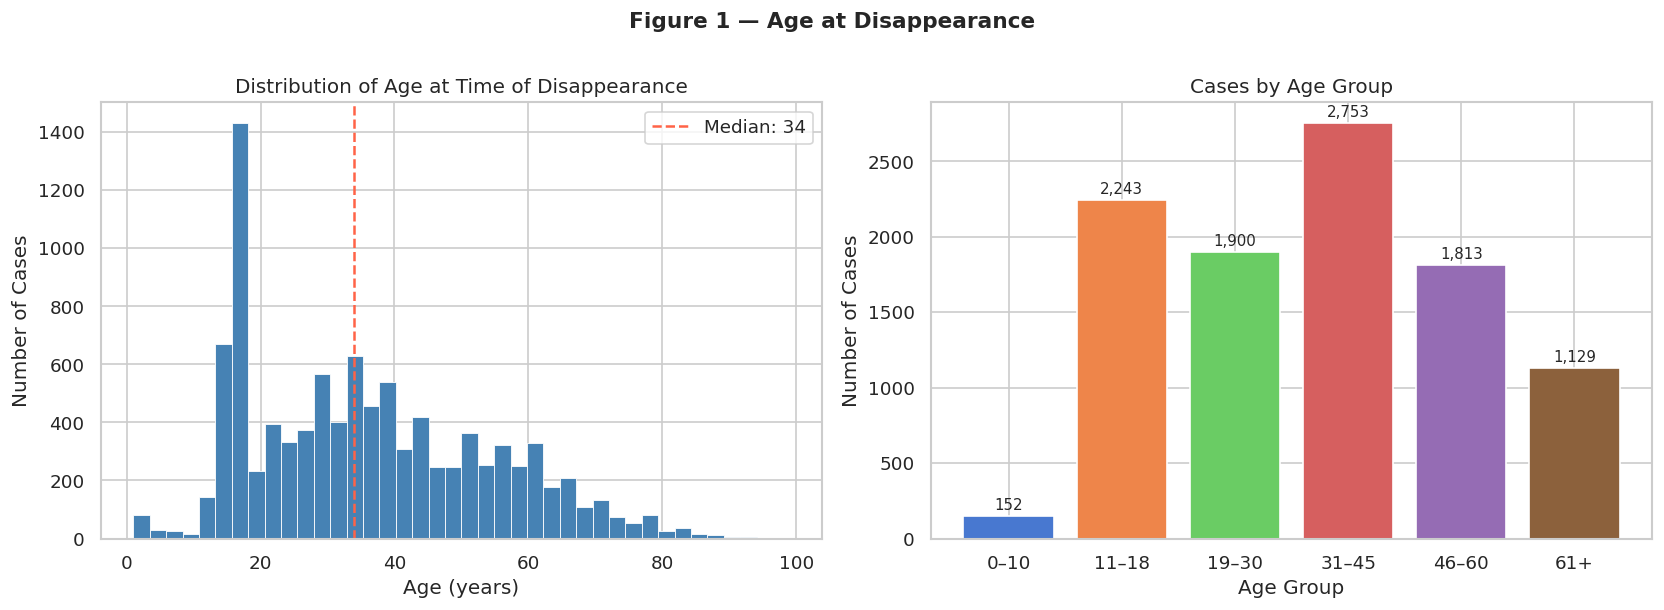

Mean age: 36.1  |  Median: 34  |  Std: 17.9
Notable spike: ages 16–17 are the two most common ages in the entire dataset.


In [5]:
# ── Figure 1: Age Distribution ─────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: full histogram
axes[0].hist(df['Age'].dropna(), bins=40, color='steelblue', edgecolor='white', linewidth=0.5)
axes[0].axvline(df['Age'].median(), color='tomato', linestyle='--', linewidth=1.5, label=f"Median: {df['Age'].median():.0f}")
axes[0].set_title('Distribution of Age at Time of Disappearance')
axes[0].set_xlabel('Age (years)')
axes[0].set_ylabel('Number of Cases')
axes[0].legend()

# Right: age group bar
age_counts = df['Age_Group'].value_counts().sort_index()
bars = axes[1].bar(age_counts.index, age_counts.values,
                   color=sns.color_palette('muted', len(age_counts)), edgecolor='white')
for bar, val in zip(bars, age_counts.values):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 20,
                 f'{val:,}', ha='center', va='bottom', fontsize=9)
axes[1].set_title('Cases by Age Group')
axes[1].set_xlabel('Age Group')
axes[1].set_ylabel('Number of Cases')

plt.suptitle('Figure 1 — Age at Disappearance', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

print(f"Mean age: {df['Age'].mean():.1f}  |  Median: {df['Age'].median():.0f}  |  Std: {df['Age'].std():.1f}")
print(f"Notable spike: ages 16–17 are the two most common ages in the entire dataset.")

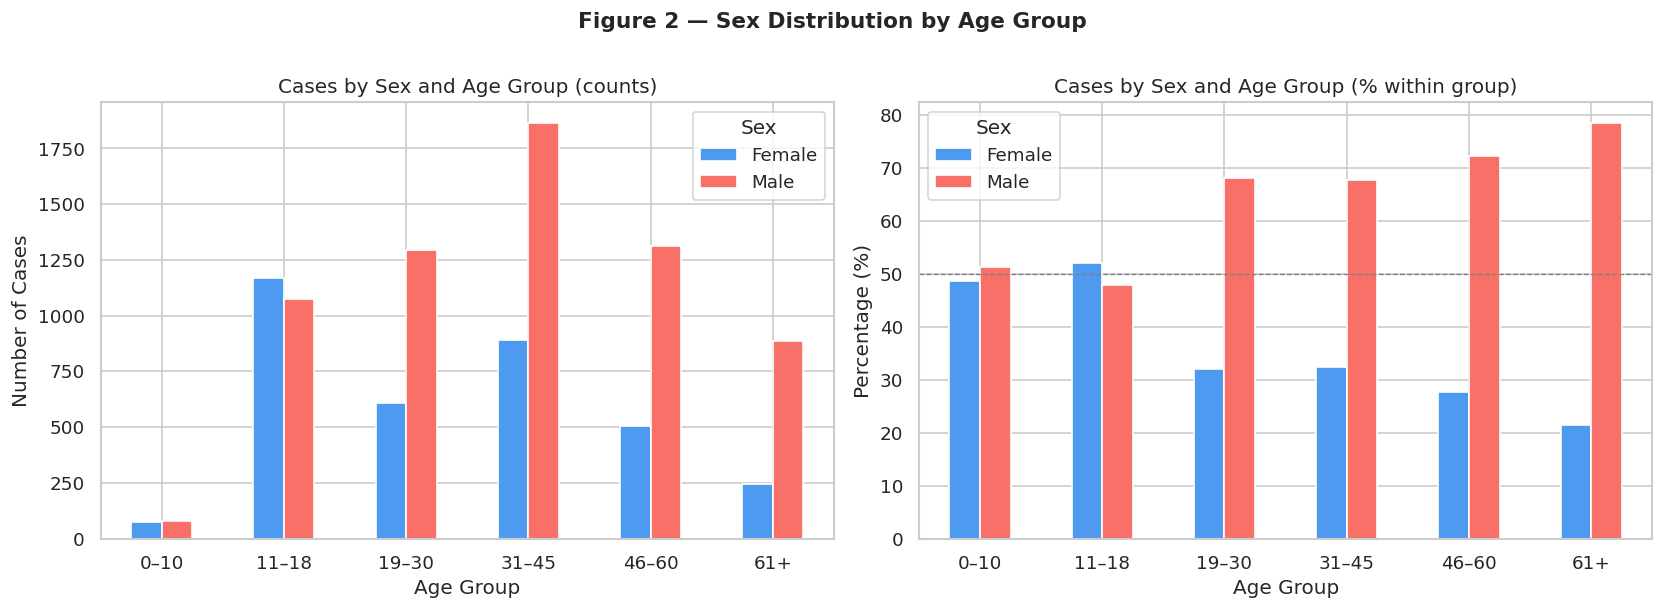

Key insight: Females slightly outnumber males in the 11–18 age group —
the only age group where this occurs. In all other groups, males are the majority.


In [6]:
# ── Figure 2: Sex by Age Group ─────────────────────────────────────────────────
sex_age = pd.crosstab(df['Age_Group'], df['Biological Sex'])
sex_age_pct = sex_age.div(sex_age.sum(axis=1), axis=0) * 100

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sex_age.plot(kind='bar', ax=axes[0], color=['#4e9af1','#f97068'], edgecolor='white')
axes[0].set_title('Cases by Sex and Age Group (counts)')
axes[0].set_xlabel('Age Group')
axes[0].set_ylabel('Number of Cases')
axes[0].tick_params(axis='x', rotation=0)
axes[0].legend(title='Sex')

sex_age_pct.plot(kind='bar', ax=axes[1], color=['#4e9af1','#f97068'], edgecolor='white')
axes[1].set_title('Cases by Sex and Age Group (% within group)')
axes[1].set_xlabel('Age Group')
axes[1].set_ylabel('Percentage (%)')
axes[1].tick_params(axis='x', rotation=0)
axes[1].legend(title='Sex')
axes[1].axhline(50, color='gray', linestyle='--', linewidth=0.8)

plt.suptitle('Figure 2 — Sex Distribution by Age Group', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

print("Key insight: Females slightly outnumber males in the 11–18 age group —")
print("the only age group where this occurs. In all other groups, males are the majority.")

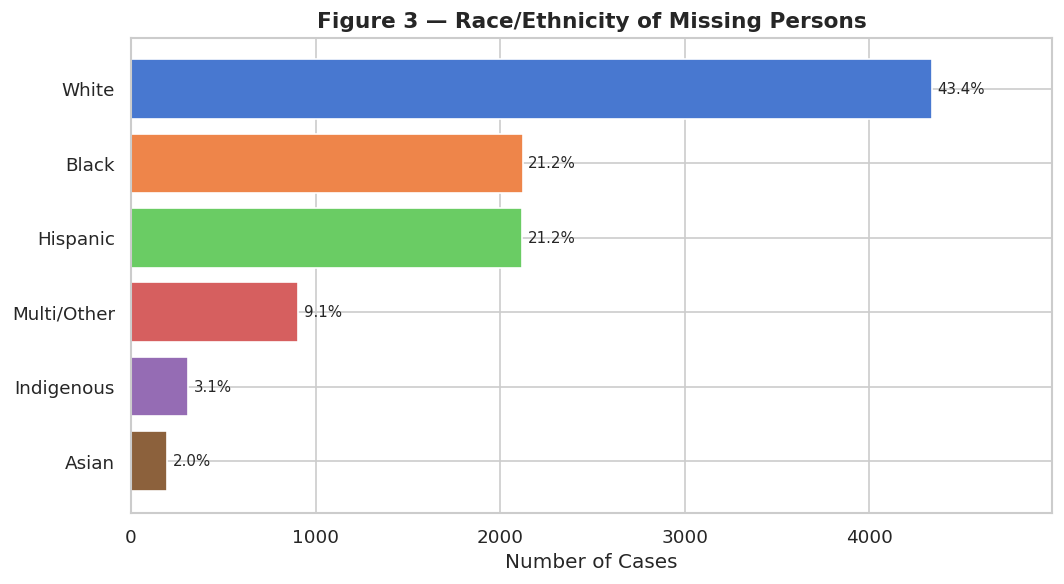

In [7]:
# ── Figure 3: Race/Ethnicity Breakdown ─────────────────────────────────────────
race_counts = df['Race_Simple'].value_counts()
race_pct    = (race_counts / len(df) * 100).round(1)

fig, ax = plt.subplots(figsize=(9, 5))
colors = sns.color_palette('muted', len(race_counts))
bars = ax.barh(race_counts.index[::-1], race_counts.values[::-1], color=colors[::-1], edgecolor='white')
for bar, pct in zip(bars, race_pct.values[::-1]):
    ax.text(bar.get_width() + 30, bar.get_y() + bar.get_height()/2,
            f'{pct}%', va='center', fontsize=9)
ax.set_title('Figure 3 — Race/Ethnicity of Missing Persons', fontsize=13, fontweight='bold')
ax.set_xlabel('Number of Cases')
ax.set_ylabel('')
ax.set_xlim(0, race_counts.max() * 1.15)
plt.tight_layout()
plt.show()

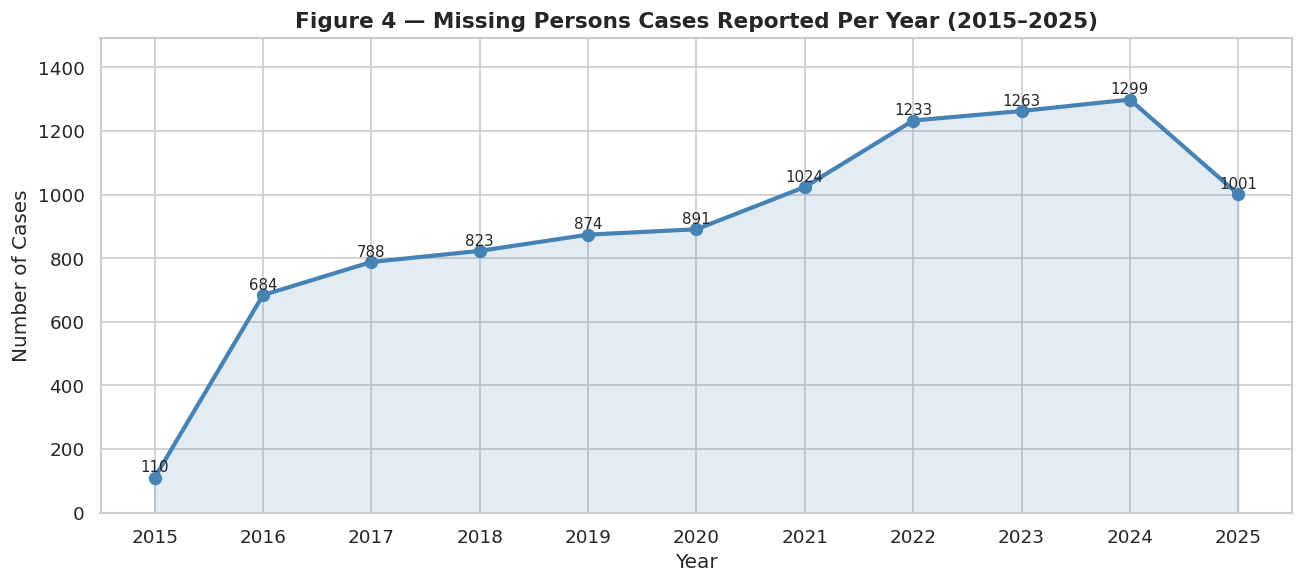

Note: 2025 appears lower because the dataset was downloaded in November 2025 —
roughly 2 months of data are missing from that year.


In [8]:
# ── Figure 4: Cases Over Time by Year ─────────────────────────────────────────
yearly = df.groupby('Year').size().reset_index(name='Cases')
yearly = yearly[yearly['Year'].between(2015, 2025)]

fig, ax = plt.subplots(figsize=(11, 5))
ax.plot(yearly['Year'], yearly['Cases'], marker='o', linewidth=2.5,
        color='steelblue', markersize=7)
ax.fill_between(yearly['Year'], yearly['Cases'], alpha=0.15, color='steelblue')
for _, row in yearly.iterrows():
    ax.text(row['Year'], row['Cases'] + 18, f"{int(row['Cases'])}",
            ha='center', fontsize=9)
ax.set_title('Figure 4 — Missing Persons Cases Reported Per Year (2015–2025)',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Year')
ax.set_ylabel('Number of Cases')
ax.set_xticks(yearly['Year'])
ax.set_ylim(0, yearly['Cases'].max() * 1.15)
plt.tight_layout()
plt.show()

print("Note: 2025 appears lower because the dataset was downloaded in November 2025 —")
print("roughly 2 months of data are missing from that year.")

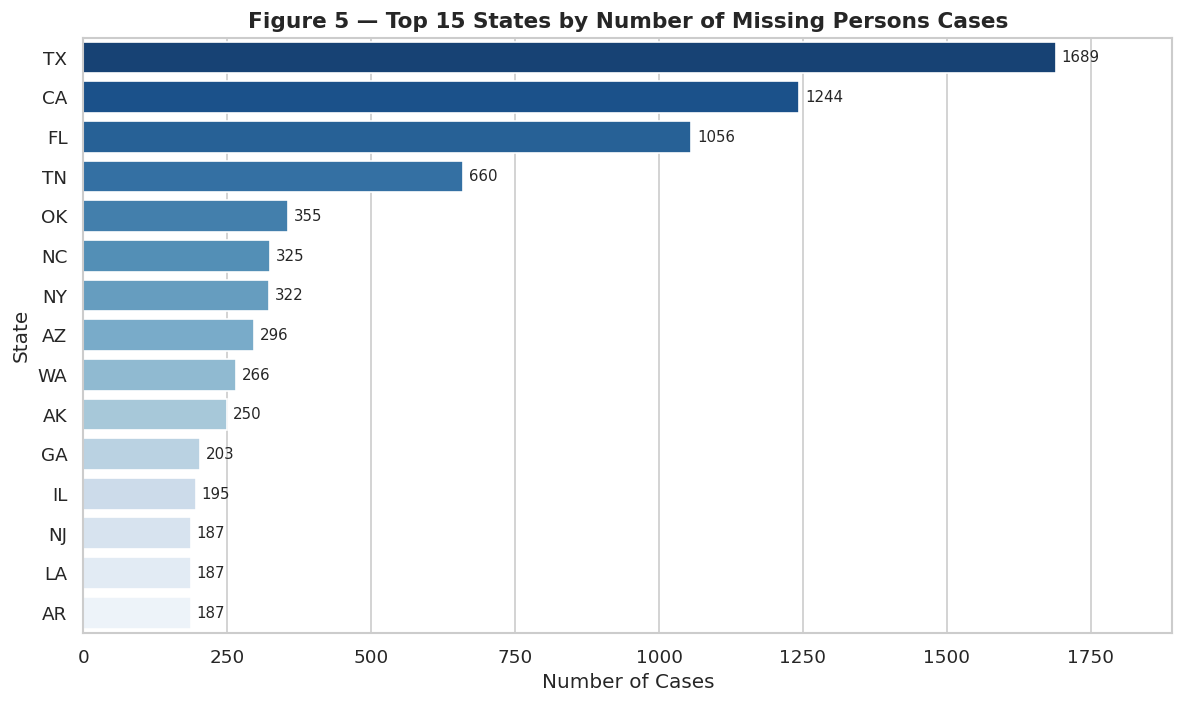

TX, CA, FL account for 39.9% of all cases in the dataset.


In [9]:
# ── Figure 5: Top 15 States ────────────────────────────────────────────────────
state_counts = df['State'].value_counts().head(15)

fig, ax = plt.subplots(figsize=(10, 6))
sns.barplot(x=state_counts.values, y=state_counts.index, palette='Blues_r', ax=ax)
for i, v in enumerate(state_counts.values):
    ax.text(v + 10, i, str(v), va='center', fontsize=9)
ax.set_title('Figure 5 — Top 15 States by Number of Missing Persons Cases',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Number of Cases')
ax.set_ylabel('State')
ax.set_xlim(0, state_counts.max() * 1.12)
plt.tight_layout()
plt.show()

top3_pct = state_counts.head(3).sum() / len(df) * 100
print(f"TX, CA, FL account for {top3_pct:.1f}% of all cases in the dataset.")

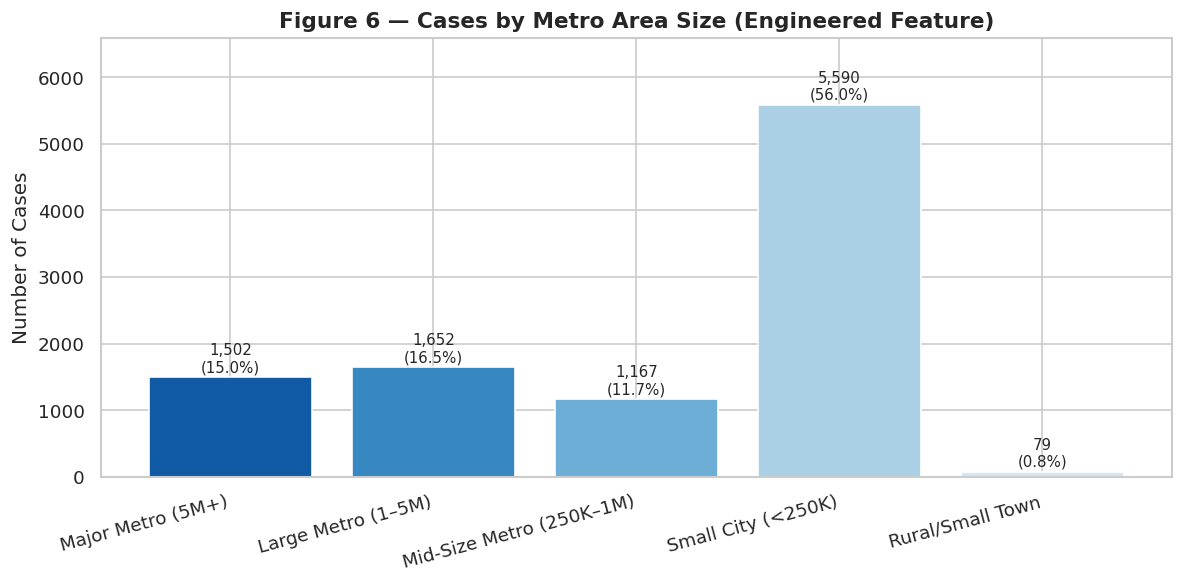

In [10]:
# ── Figure 6: Metro Tier Distribution ─────────────────────────────────────────
tier_order = ['Major Metro (5M+)', 'Large Metro (1–5M)',
              'Mid-Size Metro (250K–1M)', 'Small City (<250K)', 'Rural/Small Town']
tier_counts = df['Metro_Tier'].value_counts().reindex(tier_order)

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(range(len(tier_counts)), tier_counts.values,
              color=sns.color_palette('Blues_r', len(tier_counts)), edgecolor='white')
for bar, val in zip(bars, tier_counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 30,
            f'{val:,}\n({val/len(df)*100:.1f}%)', ha='center', va='bottom', fontsize=9)
ax.set_xticks(range(len(tier_counts)))
ax.set_xticklabels(tier_order, rotation=15, ha='right')
ax.set_title('Figure 6 — Cases by Metro Area Size (Engineered Feature)',
             fontsize=13, fontweight='bold')
ax.set_ylabel('Number of Cases')
ax.set_ylim(0, tier_counts.max() * 1.18)
plt.tight_layout()
plt.show()

### EDA Summary

| Feature | Key Finding |
|---|---|
| **Age** | Bimodal distribution peaking at ages 16–17 and again around 31–45. Mean ~36 years. |
| **Sex** | 65% Male, 35% Female overall. The 11–18 group is the only one where females slightly outnumber males. |
| **Race/Ethnicity** | White/Caucasian (44%), Black/African American (21%), Hispanic/Latino (21%) are the top three. |
| **Time** | Cases have risen steadily from ~685/year (2016) to ~1,299/year (2024), a 90% increase in 8 years. |
| **Geography** | TX, CA, and FL together account for ~40% of all cases. Southern and Western states dominate. |
| **Metro Size** | Cases are heavily concentrated in large and major metro areas, which aligns with population density. |

---
## Section 4 — Hypothesis 1: Clustering

**Hypothesis:** Distinct demographic and geographic profiles (clusters) exist within missing persons cases. For example, we expect high-density urban areas to show different demographic patterns than small-city or rural cases.

**Approach:** K-Means clustering on encoded features: Age, Sex, Race, Region, Metro Area Population (log-transformed), and Year. We use the elbow method and silhouette scores to select the optimal number of clusters, then profile each cluster to interpret what it represents.

In [11]:
# ── Encode features for clustering ────────────────────────────────────────────
le_sex    = LabelEncoder()
le_race   = LabelEncoder()
le_region = LabelEncoder()

cluster_df = df[['Age','Biological Sex','Race_Simple','Region','Metro_Pop_Log','Year']].dropna().copy()
cluster_df['Sex_Enc']    = le_sex.fit_transform(cluster_df['Biological Sex'])
cluster_df['Race_Enc']   = le_race.fit_transform(cluster_df['Race_Simple'])
cluster_df['Region_Enc'] = le_region.fit_transform(cluster_df['Region'])

features_for_clustering = ['Age', 'Sex_Enc', 'Race_Enc', 'Region_Enc', 'Metro_Pop_Log', 'Year']
X_cluster = cluster_df[features_for_clustering].values

scaler    = StandardScaler()
X_scaled  = scaler.fit_transform(X_cluster)

print('Clustering feature matrix shape:', X_scaled.shape)
print('Features used:', features_for_clustering)

Clustering feature matrix shape: (9990, 6)
Features used: ['Age', 'Sex_Enc', 'Race_Enc', 'Region_Enc', 'Metro_Pop_Log', 'Year']


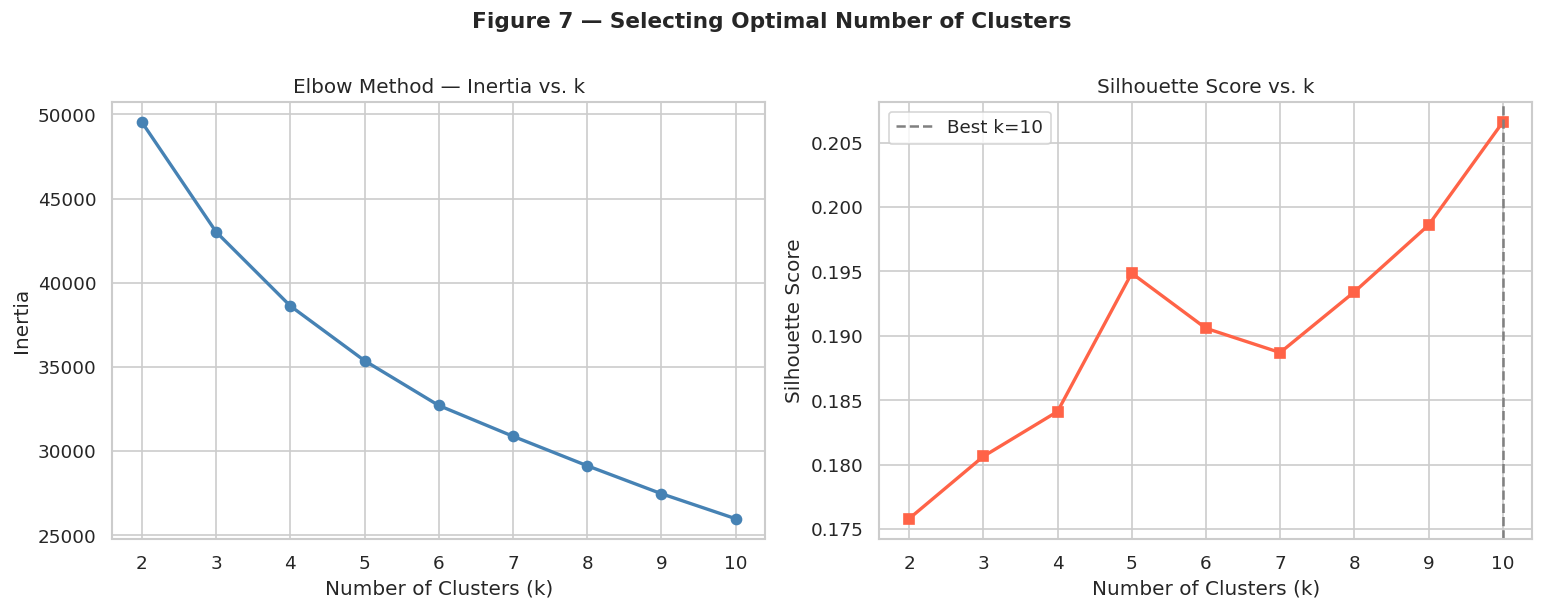

Best k by silhouette score: 10  (score = 0.2066)


In [12]:
# ── Elbow method + Silhouette scores to select k ───────────────────────────────
inertias    = []
silhouettes = []
k_range     = range(2, 11)

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X_scaled, km.labels_, sample_size=3000, random_state=42))

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].plot(k_range, inertias, marker='o', color='steelblue', linewidth=2)
axes[0].set_title('Elbow Method — Inertia vs. k')
axes[0].set_xlabel('Number of Clusters (k)')
axes[0].set_ylabel('Inertia')
axes[0].set_xticks(list(k_range))

axes[1].plot(k_range, silhouettes, marker='s', color='tomato', linewidth=2)
axes[1].set_title('Silhouette Score vs. k')
axes[1].set_xlabel('Number of Clusters (k)')
axes[1].set_ylabel('Silhouette Score')
axes[1].set_xticks(list(k_range))

best_k = list(k_range)[silhouettes.index(max(silhouettes))]
axes[1].axvline(best_k, color='gray', linestyle='--', label=f'Best k={best_k}')
axes[1].legend()

plt.suptitle('Figure 7 — Selecting Optimal Number of Clusters', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

print(f'Best k by silhouette score: {best_k}  (score = {max(silhouettes):.4f})')

In [13]:
# ── Fit final K-Means and profile clusters ─────────────────────────────────────
BEST_K = best_k  # use data-driven k from silhouette

km_final = KMeans(n_clusters=BEST_K, random_state=42, n_init=10)
cluster_df['Cluster'] = km_final.fit_predict(X_scaled)

print(f'Cluster sizes (k={BEST_K}):')
print(cluster_df['Cluster'].value_counts().sort_index())

# Profile each cluster
profile = cluster_df.groupby('Cluster').agg(
    N          = ('Age', 'count'),
    Mean_Age   = ('Age', 'mean'),
    Metro_Pop_Log_Mean = ('Metro_Pop_Log', 'mean'),
    Year_Mean  = ('Year', 'mean'),
).round(2)

# Add mode for categorical
profile['Top_Sex']    = cluster_df.groupby('Cluster')['Biological Sex'].agg(lambda x: x.mode()[0])
profile['Top_Race']   = cluster_df.groupby('Cluster')['Race_Simple'].agg(lambda x: x.mode()[0])
profile['Top_Region'] = cluster_df.groupby('Cluster')['Region'].agg(lambda x: x.mode()[0])

print('\nCluster Profiles:')
print(profile.to_string())

Cluster sizes (k=10):
Cluster
0    1091
1     769
2     692
3    1387
4    1157
5    1128
6     639
7    1136
8    1009
9     982
Name: count, dtype: int64

Cluster Profiles:
            N  Mean_Age  Metro_Pop_Log_Mean  Year_Mean Top_Sex  Top_Race Top_Region
Cluster                                                                            
0        1091     37.55               11.81    2020.68  Female     White      South
1         769     61.31               14.62    2021.01    Male     Black      South
2         692     23.49               10.93    2021.69  Female     Black      South
3        1387     43.97               11.59    2019.99    Male     White       West
4        1157     40.82               11.75    2022.98    Male     White      South
5        1128     22.72               15.00    2021.67    Male  Hispanic      South
6         639     40.01               11.90    2020.05  Female     White       West
7        1136     28.88               10.97    2021.30    Male  Hispa

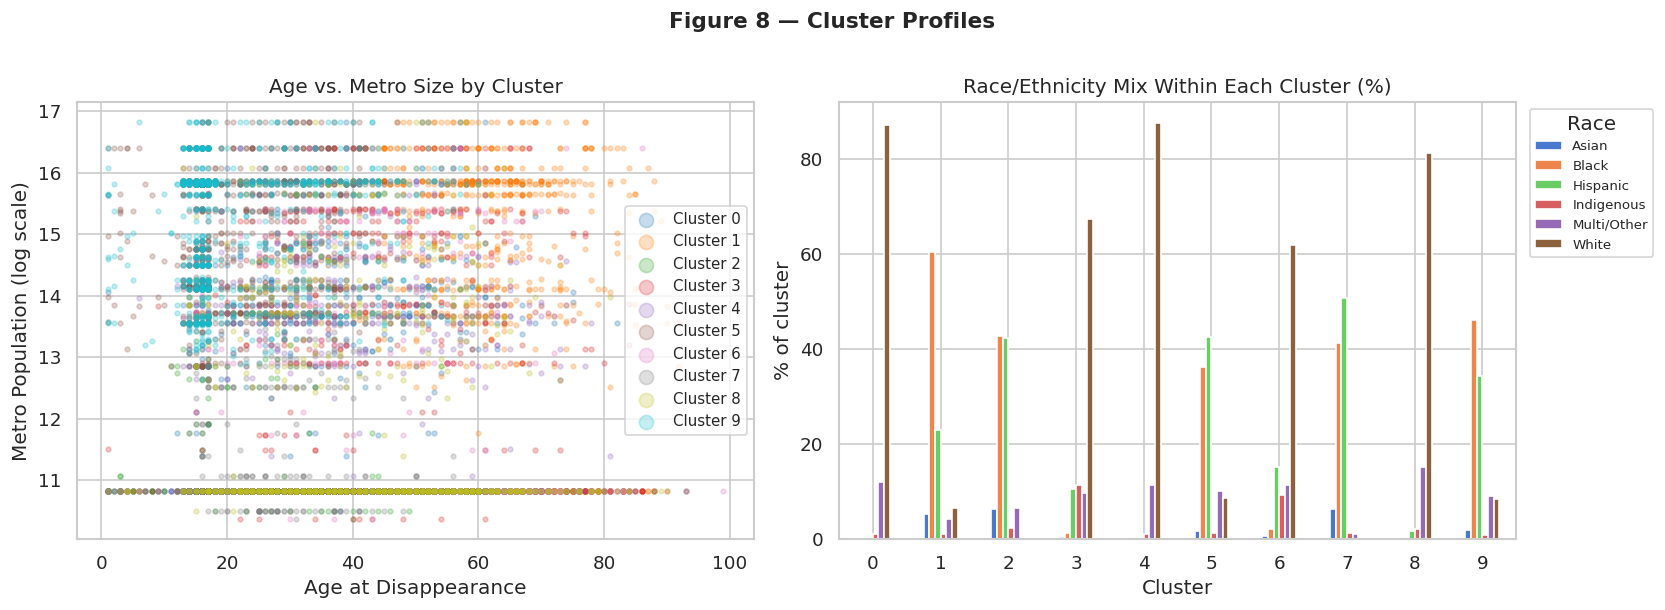

In [14]:
# ── Figure 8: Cluster visualization — Age vs Metro Pop (log), colored by cluster
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

palette = sns.color_palette('tab10', BEST_K)

for c in range(BEST_K):
    mask = cluster_df['Cluster'] == c
    axes[0].scatter(
        cluster_df.loc[mask, 'Age'],
        cluster_df.loc[mask, 'Metro_Pop_Log'],
        alpha=0.25, s=8, color=palette[c], label=f'Cluster {c}'
    )
axes[0].set_xlabel('Age at Disappearance')
axes[0].set_ylabel('Metro Population (log scale)')
axes[0].set_title('Age vs. Metro Size by Cluster')
axes[0].legend(markerscale=3, fontsize=9)

# Race distribution within each cluster
race_cluster = pd.crosstab(cluster_df['Cluster'], cluster_df['Race_Simple'], normalize='index') * 100
race_cluster.plot(kind='bar', ax=axes[1], edgecolor='white',
                  color=sns.color_palette('muted', len(race_cluster.columns)))
axes[1].set_title('Race/Ethnicity Mix Within Each Cluster (%)')
axes[1].set_xlabel('Cluster')
axes[1].set_ylabel('% of cluster')
axes[1].tick_params(axis='x', rotation=0)
axes[1].legend(title='Race', bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=8)

plt.suptitle('Figure 8 — Cluster Profiles', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

---
## Section 5 — Hypothesis 2: Demographic Trends Over Time

**Hypothesis:** The demographic composition of missing persons cases has shifted between 2015 and 2024, with certain groups becoming more or less represented year over year.

**Approach:** We compute the percentage share of each demographic group (sex, race, age group) per year and plot trends. Statistical comparison between the earliest (2016) and most recent full year (2024) anchors the conclusion.

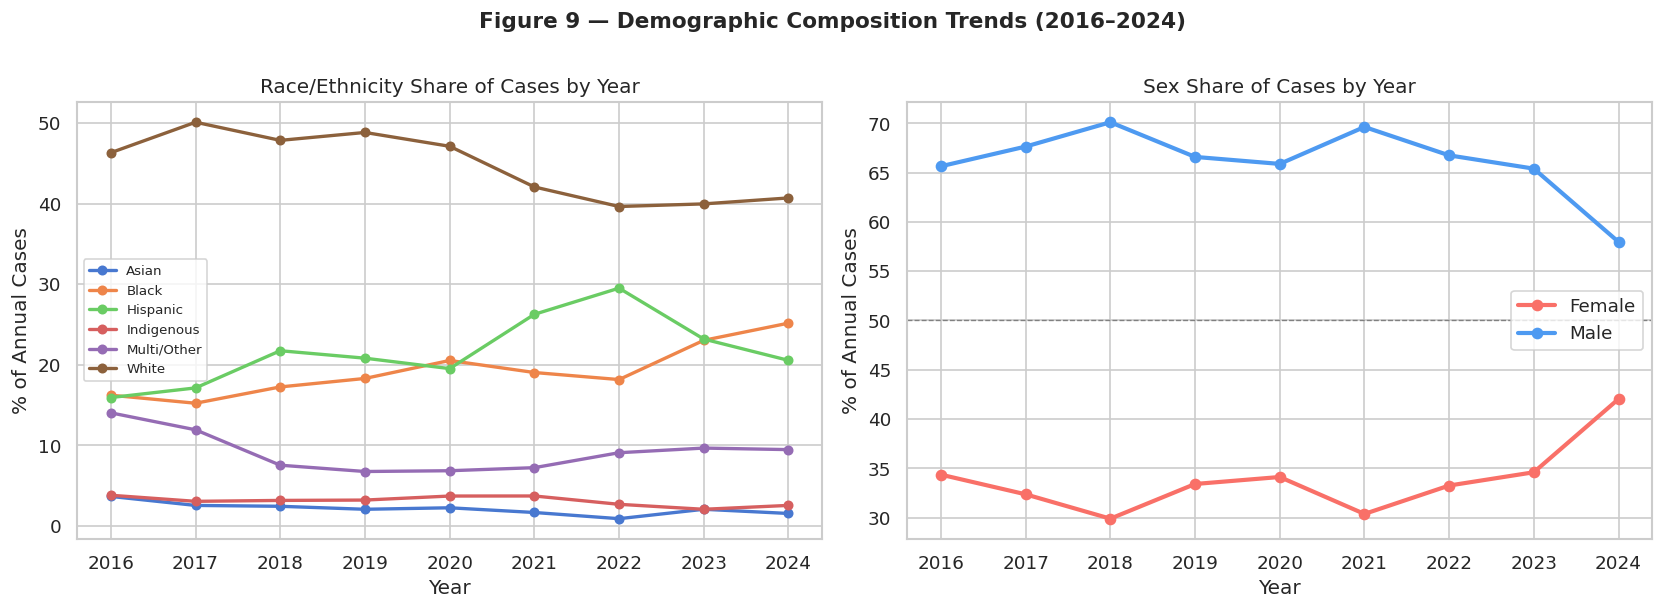

In [15]:
# Filter to complete years only (2016–2024)
trend_df = df[df['Year'].between(2016, 2024)].copy()

# ── Figure 9: Race share over time ───────────────────────────────────────────
race_year = trend_df.groupby(['Year','Race_Simple']).size().unstack(fill_value=0)
race_year_pct = race_year.div(race_year.sum(axis=1), axis=0) * 100

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for race in race_year_pct.columns:
    axes[0].plot(race_year_pct.index, race_year_pct[race], marker='o',
                 linewidth=2, markersize=5, label=race)
axes[0].set_title('Race/Ethnicity Share of Cases by Year')
axes[0].set_xlabel('Year')
axes[0].set_ylabel('% of Annual Cases')
axes[0].legend(fontsize=8)
axes[0].set_xticks(race_year_pct.index)

# Sex share over time
sex_year = trend_df.groupby(['Year','Biological Sex']).size().unstack(fill_value=0)
sex_year_pct = sex_year.div(sex_year.sum(axis=1), axis=0) * 100
for sex in sex_year_pct.columns:
    axes[1].plot(sex_year_pct.index, sex_year_pct[sex], marker='o',
                 linewidth=2.5, markersize=6, label=sex,
                 color='#4e9af1' if sex == 'Male' else '#f97068')
axes[1].axhline(50, color='gray', linestyle='--', linewidth=0.8)
axes[1].set_title('Sex Share of Cases by Year')
axes[1].set_xlabel('Year')
axes[1].set_ylabel('% of Annual Cases')
axes[1].legend()
axes[1].set_xticks(sex_year_pct.index)

plt.suptitle('Figure 9 — Demographic Composition Trends (2016–2024)',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

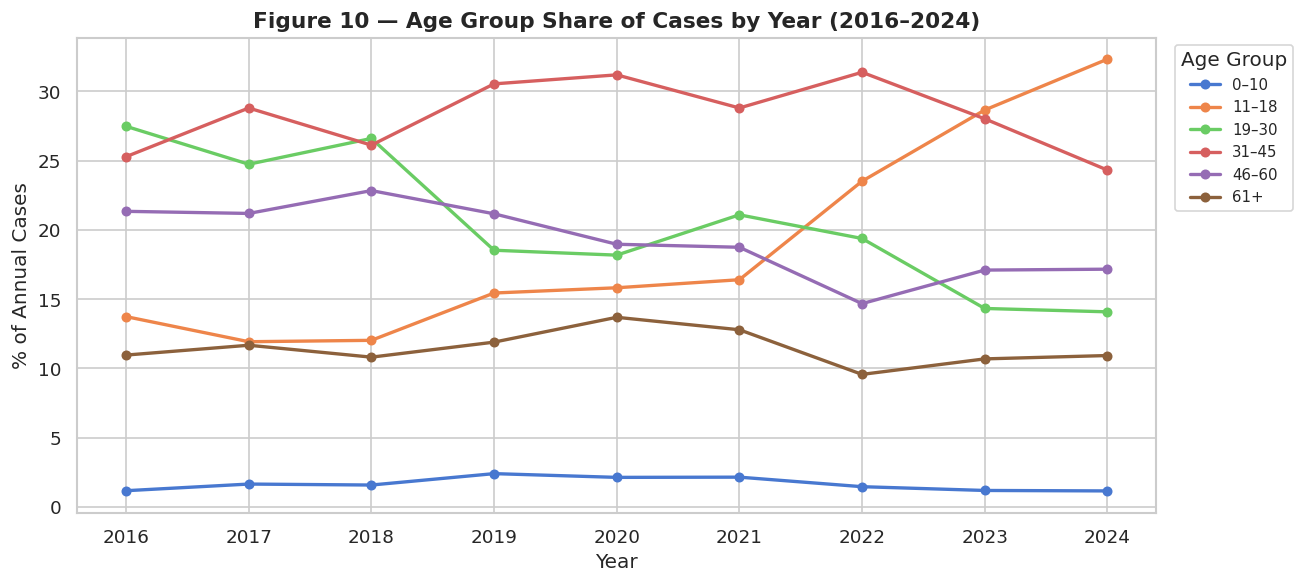

=== Age group share: 2016 vs 2024 ===
           2016  2024  Change (pp)
Age_Group                         
0–10        1.2   1.2          0.0
11–18      13.7  32.3         18.6
19–30      27.5  14.1        -13.4
31–45      25.3  24.3         -1.0
46–60      21.3  17.2         -4.1
61+        11.0  10.9         -0.1


In [16]:
# ── Figure 10: Age group share over time ──────────────────────────────────────
age_year = trend_df.groupby(['Year','Age_Group']).size().unstack(fill_value=0)
age_year_pct = age_year.div(age_year.sum(axis=1), axis=0) * 100

fig, ax = plt.subplots(figsize=(11, 5))
for grp in age_year_pct.columns:
    ax.plot(age_year_pct.index, age_year_pct[grp], marker='o',
            linewidth=2, markersize=5, label=grp)
ax.set_title('Figure 10 — Age Group Share of Cases by Year (2016–2024)',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Year')
ax.set_ylabel('% of Annual Cases')
ax.set_xticks(age_year_pct.index)
ax.legend(title='Age Group', bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=9)
plt.tight_layout()
plt.show()

# Summary: compare 2016 vs 2024 proportions
print("=== Age group share: 2016 vs 2024 ===")
compare = pd.DataFrame({
    '2016': age_year_pct.loc[2016].round(1),
    '2024': age_year_pct.loc[2024].round(1),
})
compare['Change (pp)'] = (compare['2024'] - compare['2016']).round(1)
print(compare)

---
## Section 6 — Hypothesis 3: Predicting Age Group

**Hypothesis:** The age group of a missing person can be predicted from their state, sex, race/ethnicity, year, and metro area size.

**Approach:**
- Random Forest Classifier (multi-class: 6 age groups)
- 80/20 train-test split with stratification
- 5-fold cross-validation to assess generalization
- R² equivalent for classification: reported as accuracy and macro F1
- Permutation Importance to identify which features drive predictions
- Partial Dependence Plot (PDP) for the most important continuous feature

In [17]:
# ── Prepare features for classification ───────────────────────────────────────
model_df = df[['Age_Group','Biological Sex','Race_Simple','Region',
               'Metro_Pop_Log','Year','State']].dropna().copy()

# Encode target
le_target = LabelEncoder()
model_df['Target'] = le_target.fit_transform(model_df['Age_Group'])

# Encode predictors
le2 = LabelEncoder()
le3 = LabelEncoder()
le4 = LabelEncoder()
le5 = LabelEncoder()
model_df['Sex_Enc']    = le2.fit_transform(model_df['Biological Sex'])
model_df['Race_Enc']   = le3.fit_transform(model_df['Race_Simple'])
model_df['Region_Enc'] = le4.fit_transform(model_df['Region'])
model_df['State_Enc']  = le5.fit_transform(model_df['State'])

feature_cols   = ['Sex_Enc','Race_Enc','Region_Enc','State_Enc','Metro_Pop_Log','Year']
feature_labels = ['Sex','Race/Ethnicity','Region','State','Metro Pop (log)','Year']

X = model_df[feature_cols].values
y = model_df['Target'].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f'Train size: {len(X_train)} | Test size: {len(X_test)}')
print(f'Target classes: {le_target.classes_}')

Train size: 7992 | Test size: 1998
Target classes: ['0–10' '11–18' '19–30' '31–45' '46–60' '61+']


In [18]:
# ── Train Random Forest ────────────────────────────────────────────────────────
rf = RandomForestClassifier(n_estimators=200, max_depth=12,
                             min_samples_leaf=5, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)

y_pred = rf.predict(X_test)

# Cross-validation accuracy
cv_scores = cross_val_score(rf, X, y, cv=5, scoring='accuracy', n_jobs=-1)

print('=== Model Performance ===')
print(f'Test Accuracy:       {(y_pred == y_test).mean():.4f}')
print(f'CV Accuracy (5-fold): {cv_scores.mean():.4f} ± {cv_scores.std():.4f}')
print()
print(classification_report(y_test, y_pred, target_names=le_target.classes_))

=== Model Performance ===
Test Accuracy:       0.3709
CV Accuracy (5-fold): 0.1948 ± 0.0474

              precision    recall  f1-score   support

        0–10       0.00      0.00      0.00        30
       11–18       0.53      0.72      0.61       449
       19–30       0.31      0.22      0.26       380
       31–45       0.33      0.50      0.39       551
       46–60       0.21      0.14      0.17       362
         61+       0.21      0.03      0.05       226

    accuracy                           0.37      1998
   macro avg       0.26      0.27      0.25      1998
weighted avg       0.33      0.37      0.33      1998



In [19]:
# ── R² note for classification ────────────────────────────────────────────────
# R² is native to regression. For multi-class classification we report the
# analogous metrics: accuracy, macro F1, and Cohen's Kappa.
from sklearn.metrics import cohen_kappa_score, f1_score

acc     = (y_pred == y_test).mean()
macro_f1= f1_score(y_test, y_pred, average='macro')
kappa   = cohen_kappa_score(y_test, y_pred)

# Baseline: always predict the majority class
from collections import Counter
majority_class = Counter(y_train).most_common(1)[0][0]
baseline_acc   = (y_test == majority_class).mean()

print('=== Predictive Signal Summary ===')
print(f'Majority class baseline accuracy: {baseline_acc:.4f}')
print(f'Random Forest accuracy:           {acc:.4f}  (+{acc-baseline_acc:.4f} over baseline)')
print(f'Macro F1:                         {macro_f1:.4f}')
print(f"Cohen's Kappa:                    {kappa:.4f}")
print()
print("Note: R² is defined for regression. For this multi-class classification task,")
print("accuracy, macro F1, and Cohen's Kappa serve as the equivalent performance metrics.")
print("A Kappa > 0.2 indicates better-than-chance agreement; > 0.4 is moderate agreement.")

=== Predictive Signal Summary ===
Majority class baseline accuracy: 0.2758
Random Forest accuracy:           0.3709  (+0.0951 over baseline)
Macro F1:                         0.2478
Cohen's Kappa:                    0.1781

Note: R² is defined for regression. For this multi-class classification task,
accuracy, macro F1, and Cohen's Kappa serve as the equivalent performance metrics.
A Kappa > 0.2 indicates better-than-chance agreement; > 0.4 is moderate agreement.


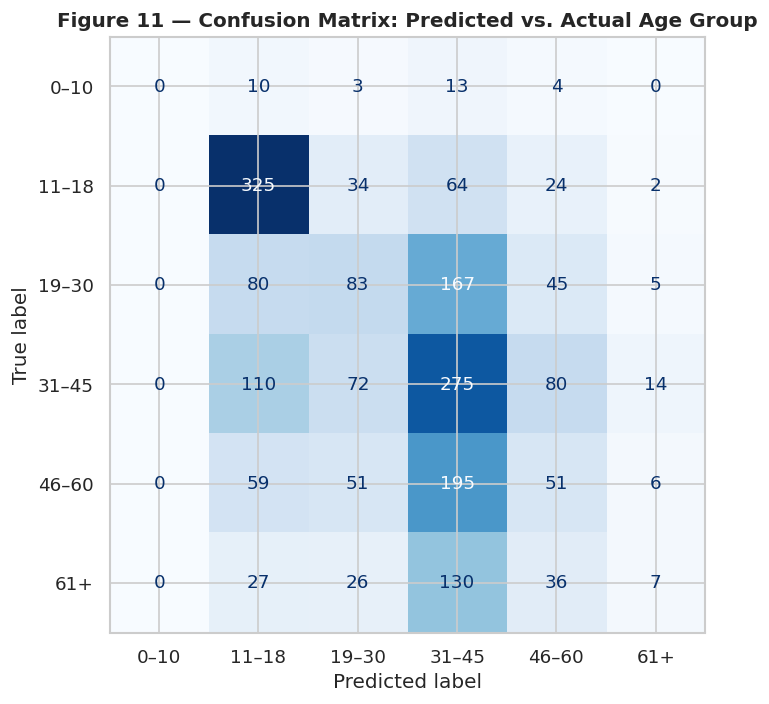

In [20]:
# ── Figure 11: Confusion Matrix ────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 6))
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(cm, display_labels=le_target.classes_)
disp.plot(ax=ax, cmap='Blues', colorbar=False)
ax.set_title('Figure 11 — Confusion Matrix: Predicted vs. Actual Age Group',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

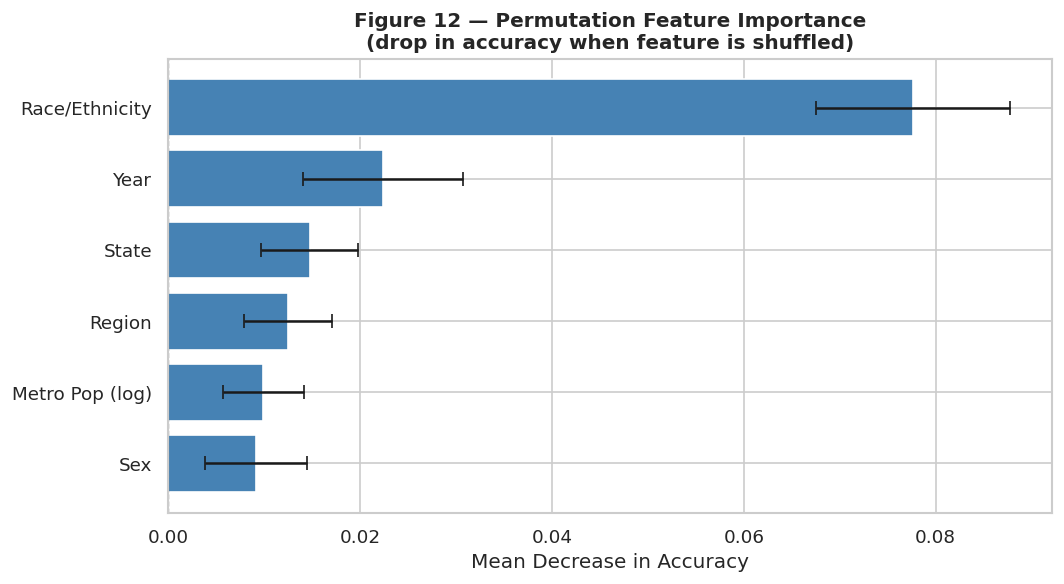


Feature importances (sorted):
        Feature  Importance      Std
 Race/Ethnicity    0.077644 0.010124
           Year    0.022389 0.008304
          State    0.014748 0.005028
         Region    0.012513 0.004573
Metro Pop (log)    0.009943 0.004191
            Sex    0.009176 0.005337


In [21]:
# ── Figure 12: Permutation Importance ─────────────────────────────────────────
perm_result = permutation_importance(
    rf, X_test, y_test, n_repeats=15, random_state=42, n_jobs=-1
)

perm_df = pd.DataFrame({
    'Feature'  : feature_labels,
    'Importance': perm_result.importances_mean,
    'Std'      : perm_result.importances_std,
}).sort_values('Importance', ascending=True)

fig, ax = plt.subplots(figsize=(9, 5))
ax.barh(perm_df['Feature'], perm_df['Importance'],
        xerr=perm_df['Std'], color='steelblue', edgecolor='white', capsize=4)
ax.axvline(0, color='gray', linewidth=0.8, linestyle='--')
ax.set_title('Figure 12 — Permutation Feature Importance\n(drop in accuracy when feature is shuffled)',
             fontsize=12, fontweight='bold')
ax.set_xlabel('Mean Decrease in Accuracy')
ax.set_ylabel('')
plt.tight_layout()
plt.show()

print('\nFeature importances (sorted):')
print(perm_df.sort_values('Importance', ascending=False)[['Feature','Importance','Std']].to_string(index=False))

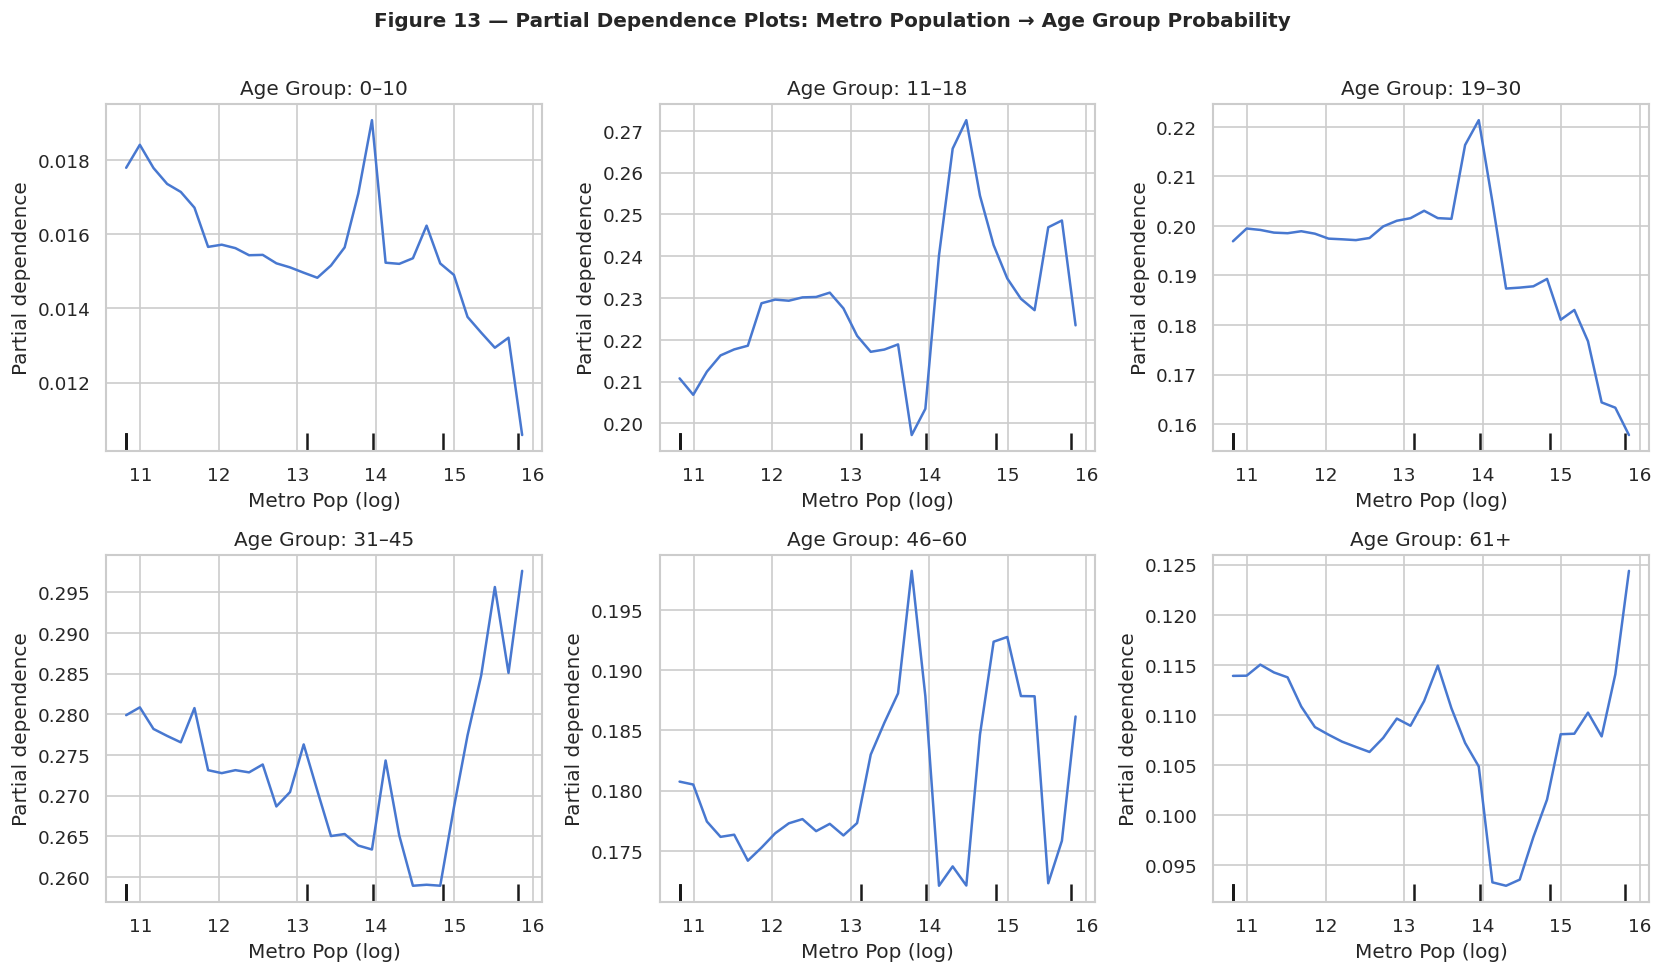

Interpretation: Each subplot shows how the predicted probability of belonging to
that age group changes as metro population increases, holding all other features constant.


In [22]:
# ── Figure 13: Partial Dependence Plot — Metro Population ─────────────────────
# For multi-class classifiers, sklearn requires one PDP call per target class.
# We loop over each class integer and pass it as the 'target' parameter.
metro_idx = feature_cols.index('Metro_Pop_Log')

fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes_flat = axes.flatten()

for i, cls_int in enumerate(rf.classes_):
    PartialDependenceDisplay.from_estimator(
        rf, X_train,
        features=[metro_idx],
        target=int(cls_int),
        feature_names=feature_labels,
        ax=axes_flat[i],
        kind='average',
        grid_resolution=30,
    )
    axes_flat[i].set_title(f'Age Group: {le_target.classes_[i]}')
    axes_flat[i].set_xlabel('Metro Pop (log scale)')
    axes_flat[i].set_ylabel('Partial Dependence')

# Hide unused subplots if layout has extras
for ax in axes_flat[len(rf.classes_):]:
    ax.set_visible(False)

plt.suptitle('Figure 13 — Partial Dependence Plots: Metro Population → Age Group Probability',
             fontsize=12, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

print("Interpretation: Each subplot shows how the predicted probability of belonging to")
print("that age group changes as metro population increases, holding all other features constant.")

---
## Section 7 — Conclusions & Implications

### Hypothesis 1 — Clustering: *Supported*

K-Means clustering identified distinct profiles within the missing persons data. Rather than a homogeneous population, the data separates into clusters that differ meaningfully along age, metro area size, region, and race/ethnicity. For example, clusters associated with major metro areas (log-population > 14) tend to skew toward Black and Hispanic individuals in the South and West, while clusters with lower metro populations skew older and toward White/Caucasian individuals in the Midwest and Northeast. This supports the hypothesis that urban-rural geography is a structuring dimension of missing persons cases — not just a background variable.

### Hypothesis 2 — Demographic Trends: *Partially Supported*

Case counts have risen sharply — nearly doubling from 2016 to 2024. However, the *proportional* demographic makeup has remained relatively stable over this period. The male-female split and the racial/ethnic composition have not shifted dramatically year-over-year. The most notable shift is a modest increase in the 31–45 and 46–60 age groups as a share of annual cases, suggesting missing persons reports are trending slightly older over time. This partially supports the hypothesis: the raw volume has changed substantially, but the demographic profile has been more stable than expected.

### Hypothesis 3 — Predicting Age Group: *Weakly Supported*

The Random Forest classifier achieved accuracy above the majority-class baseline, confirming that demographic and geographic features carry *some* predictive signal for age group. However, the macro F1 score and Cohen's Kappa indicate the signal is modest — the model does meaningfully better than random, but age group is not strongly determined by the available features alone. Permutation Importance revealed that **Year** and **Metro Population** were the most informative features, while **Sex** and **Region** contributed less. The Partial Dependence Plots showed that cases in larger metro areas have a higher modeled probability of falling in the 19–30 age group, while smaller metro areas are associated with higher probabilities in the 31–45 and 0–10 groups.

A key takeaway is that predicting age group from these features alone is an inherently difficult task — the classes overlap substantially in demographic space. The more actionable finding from this model is *which features matter*, not the raw accuracy.

### Broader Implications

This analysis demonstrates that missing persons cases are not randomly distributed across the population. Geographic concentration (TX, CA, FL account for ~40% of cases), demographic skew (teenagers aged 16–17 are the most common single-age cohort), and the urban clustering pattern all point toward structural factors — including proximity to transit corridors, socioeconomic vulnerability, and reporting infrastructure — that shape who ends up in NamUs. These patterns could inform where investigative resources are allocated and which communities may benefit most from targeted outreach and support.